# Dynamic organization benchmark

This notebook compares several operationalizations of systematic semantic movement:

1. Ridge next-turn prediction
2. Same-conversation next-turn ranking
3. Hidden Markov model sequence likelihood
4. Pretrained language-model order likelihood
5. A small GRU next-turn predictor

Every score is compared with **role-preserving shuffles of the same turns**. Learned embedding models use grouped cross-validation by `video_uid`, so a topic/video never appears in both training and testing.

The primary analysis is the whole-conversation **joint trajectory**. Speaker-specific trajectories can be enabled after coverage is checked.

## 0. Optional dependencies

The Ridge and ranking methods use scikit-learn. The HMM requires `hmmlearn`; the language-model score requires `transformers` and `torch`; the GRU requires `torch`.

Install missing packages in the same environment used by this notebook:

```bash
pip install hmmlearn torch transformers statsmodels
```

Restart the kernel after installation.

In [1]:
from pathlib import Path
import copy
import math
import warnings

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
EPSILON = 1e-12

EXPORT_DIR = Path("analysis_exports")
OUTPUT_DIR = EXPORT_DIR / "dynamic_benchmark"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Primary configuration
TRAJECTORY_TYPES = ["joint"]
OUTER_FOLDS = 5
PCA_DIMENSIONS = 20
CONTEXT_LENGTH = 3

# Start with smaller values while debugging, then increase.
N_SHUFFLES_PREDICTION = 100
N_SHUFFLES_HMM = 100
N_SHUFFLES_LANGUAGE_MODEL = 20
N_SHUFFLES_GRU = 50

RUN_RIDGE_AND_RANKING = True
RUN_HMM = True
RUN_LANGUAGE_MODEL = True
RUN_GRU = True

# Whole-conversation centering removes topic location and focuses the models
# on relative movement. The same centering is used for real and shuffled order.
CENTER_WITHIN_CONVERSATION = True

## 1. Load and validate analysis inputs

Required files:

- `analysis_exports/turns_dynamic.csv`
- `analysis_exports/turn_embeddings.npy`

For the language-model method, the turn table must also contain a turn-text column such as `turn_text`, `text`, or `utterance`.

In [2]:
turns_dynamic = pd.read_csv(EXPORT_DIR / "turns_dynamic.csv")
X_turns = np.load(EXPORT_DIR / "turn_embeddings.npy")

required_columns = [
    "video_uid",
    "conversation_uid",
    "conversation_id",
    "level_label",
    "_role",
    "_turn_order",
    "_embedding_row",
]

missing = [c for c in required_columns if c not in turns_dynamic.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

turns_dynamic["video_uid"] = turns_dynamic["video_uid"].astype(str)
turns_dynamic["conversation_uid"] = turns_dynamic["conversation_uid"].astype(str)
turns_dynamic["_embedding_row"] = turns_dynamic["_embedding_row"].astype(int)
turns_dynamic["_turn_order"] = turns_dynamic["_turn_order"].astype(int)
turns_dynamic["_role"] = (
    turns_dynamic["_role"].astype(str).str.lower().str.strip()
)

if turns_dynamic["_embedding_row"].max() >= len(X_turns):
    raise ValueError("_embedding_row exceeds the embedding matrix length")

norms = np.linalg.norm(X_turns, axis=1, keepdims=True)
if np.any(norms < EPSILON):
    raise ValueError("At least one turn embedding has zero norm")
X_turns = X_turns / norms

TEXT_CANDIDATES = [
    "turn_text",
    "text",
    "utterance",
    "turn_text_clean",
]
TEXT_COLUMN = next((c for c in TEXT_CANDIDATES if c in turns_dynamic.columns), None)

print("Turns:", len(turns_dynamic))
print("Conversations:", turns_dynamic["conversation_uid"].nunique())
print("Videos/topics:", turns_dynamic["video_uid"].nunique())
print("Embedding shape:", X_turns.shape)
print("Text column:", TEXT_COLUMN)
print(turns_dynamic["level_label"].value_counts())

Turns: 2078
Conversations: 80
Videos/topics: 16
Embedding shape: (2078, 384)
Text column: None
level_label
child            479
graduate         413
expert           400
undergraduate    394
teenager         392
Name: count, dtype: int64


## 2. Construct ordered conversation sequences

`joint` retains every turn. `expert` and `partner` retain only turns assigned to that role, while preserving their original order.

In [3]:
def prepare_sequence_points(points):
    points = np.asarray(points, dtype=float)
    if CENTER_WITHIN_CONVERSATION:
        points = points - points.mean(axis=0, keepdims=True)
    return points


def build_sequences(turn_table, embeddings, trajectory_type="joint"):
    sequences = {}

    for conversation_uid, group in turn_table.groupby(
        "conversation_uid", sort=True
    ):
        group = group.sort_values("_turn_order").reset_index(drop=True)

        if trajectory_type != "joint":
            group = group[group["_role"] == trajectory_type].reset_index(drop=True)

        if len(group) < CONTEXT_LENGTH + 2:
            continue

        rows = group["_embedding_row"].to_numpy(dtype=int)
        points = prepare_sequence_points(embeddings[rows])

        texts = None
        if TEXT_COLUMN is not None:
            texts = group[TEXT_COLUMN].fillna("").astype(str).to_numpy()

        sequences[str(conversation_uid)] = {
            "conversation_uid": str(conversation_uid),
            "conversation_id": group["conversation_id"].iloc[0],
            "video_uid": str(group["video_uid"].iloc[0]),
            "level_label": group["level_label"].iloc[0],
            "trajectory_type": trajectory_type,
            "roles": group["_role"].to_numpy(),
            "points": points,
            "texts": texts,
            "n_turns": len(group),
        }

    return sequences


all_sequences = {
    trajectory_type: build_sequences(turns_dynamic, X_turns, trajectory_type)
    for trajectory_type in TRAJECTORY_TYPES
}

for trajectory_type, sequences in all_sequences.items():
    print(trajectory_type, "conversations:", len(sequences))
    print("minimum turns:", min(s["n_turns"] for s in sequences.values()))

joint conversations: 80
minimum turns: 9


## 3. Shared shuffling and scoring utilities

The role sequence remains fixed. Expert embeddings are shuffled only among expert positions, and partner embeddings only among partner positions.

In [4]:
def role_preserving_permutation(roles, rng):
    roles = np.asarray(roles)
    permutation = np.arange(len(roles))

    for role in np.unique(roles):
        positions = np.flatnonzero(roles == role)
        permutation[positions] = rng.permutation(positions)

    return permutation


def summarize_real_vs_shuffle(observed, shuffled_scores):
    shuffled_scores = np.asarray(shuffled_scores, dtype=float)
    shuffled_scores = shuffled_scores[np.isfinite(shuffled_scores)]

    if not np.isfinite(observed) or len(shuffled_scores) < 2:
        return {
            "score_observed": observed,
            "score_shuffle_mean": np.nan,
            "score_shuffle_sd": np.nan,
            "organization_gain": np.nan,
            "organization_z": np.nan,
            "p_perm_high": np.nan,
        }

    null_mean = shuffled_scores.mean()
    null_sd = shuffled_scores.std(ddof=1)
    gain = observed - null_mean
    z = gain / null_sd if null_sd > EPSILON else np.nan
    p = (1 + np.sum(shuffled_scores >= observed)) / (len(shuffled_scores) + 1)

    return {
        "score_observed": observed,
        "score_shuffle_mean": null_mean,
        "score_shuffle_sd": null_sd,
        "organization_gain": gain,
        "organization_z": z,
        "p_perm_high": p,
    }


def result_record(sequence, method, summary, fold=None):
    return {
        "video_uid": sequence["video_uid"],
        "conversation_uid": sequence["conversation_uid"],
        "conversation_id": sequence["conversation_id"],
        "level_label": sequence["level_label"],
        "trajectory_type": sequence["trajectory_type"],
        "method": method,
        "n_turns": sequence["n_turns"],
        "fold": fold,
        **summary,
    }

## 4. Ridge next-turn prediction and next-turn ranking

For each position, the feature vector contains the current semantic state, recent velocity, recent acceleration, and current/next speaker roles. Ridge predicts the next PCA position.

Prediction organization is the log MSE improvement over a persistence baseline. Ranking organization is the mean reciprocal rank of the true next turn among same-conversation, same-role candidates.

In [5]:
def transform_sequences_with_pca(sequences, train_ids, test_ids, n_components):
    train_points = np.vstack([sequences[cid]["points"] for cid in train_ids])
    dimensions = min(n_components, train_points.shape[1], len(train_points) - 1)
    pca = PCA(n_components=dimensions, whiten=True, random_state=RANDOM_SEED)
    pca.fit(train_points)

    transformed = {}
    for cid in list(train_ids) + list(test_ids):
        transformed[cid] = pca.transform(sequences[cid]["points"])

    return pca, transformed


def make_prediction_samples(z, roles, context_length=3):
    z = np.asarray(z)
    roles = np.asarray(roles)

    features = []
    targets = []
    persistence = []
    target_indices = []

    for target_index in range(context_length, len(z)):
        current = z[target_index - 1]
        velocity = z[target_index - 1] - z[target_index - 2]
        previous_velocity = z[target_index - 2] - z[target_index - 3]
        acceleration = velocity - previous_velocity

        current_role = float(roles[target_index - 1] == "expert")
        next_role = float(roles[target_index] == "expert")

        feature = np.concatenate([
            current,
            velocity,
            acceleration,
            [current_role, next_role],
        ])

        features.append(feature)
        targets.append(z[target_index])
        persistence.append(current)
        target_indices.append(target_index)

    return (
        np.asarray(features),
        np.asarray(targets),
        np.asarray(persistence),
        np.asarray(target_indices, dtype=int),
    )


def ridge_prediction_and_ranking_scores(model, z, roles):
    X, y, persistence, target_indices = make_prediction_samples(
        z, roles, CONTEXT_LENGTH
    )
    if len(X) == 0:
        return np.nan, np.nan

    predictions = model.predict(X)
    model_mse = np.mean((predictions - y) ** 2)
    persistence_mse = np.mean((persistence - y) ** 2)
    prediction_score = np.log(
        (persistence_mse + EPSILON) / (model_mse + EPSILON)
    )

    reciprocal_ranks = []
    roles = np.asarray(roles)

    for prediction, target_index in zip(predictions, target_indices):
        target_role = roles[target_index]
        candidate_indices = np.flatnonzero(roles == target_role)

        # Do not allow immediately preceding context positions as distractors.
        context_positions = set(range(target_index - CONTEXT_LENGTH, target_index))
        candidate_indices = np.array([
            i for i in candidate_indices
            if i == target_index or i not in context_positions
        ], dtype=int)

        if len(candidate_indices) < 2:
            continue

        candidate_distances = np.linalg.norm(
            z[candidate_indices] - prediction,
            axis=1,
        )
        true_location = int(np.flatnonzero(candidate_indices == target_index)[0])
        true_distance = candidate_distances[true_location]
        rank = 1 + np.sum(candidate_distances < true_distance - 1e-12)
        reciprocal_ranks.append(1.0 / rank)

    ranking_score = (
        float(np.mean(reciprocal_ranks)) if reciprocal_ranks else np.nan
    )
    return float(prediction_score), ranking_score

In [6]:
def run_ridge_and_ranking(sequences, n_shuffles=N_SHUFFLES_PREDICTION):
    conversation_ids = np.array(sorted(sequences))
    conversation_videos = np.array([sequences[cid]["video_uid"] for cid in conversation_ids])
    unique_videos = np.unique(conversation_videos)

    n_splits = min(OUTER_FOLDS, len(unique_videos))
    outer_cv = GroupKFold(n_splits=n_splits)
    rng = np.random.default_rng(RANDOM_SEED)
    records = []

    for fold, (train_index, test_index) in enumerate(
        outer_cv.split(conversation_ids, groups=conversation_videos)
    ):
        train_ids = conversation_ids[train_index]
        test_ids = conversation_ids[test_index]
        _, transformed = transform_sequences_with_pca(
            sequences, train_ids, test_ids, PCA_DIMENSIONS
        )

        train_X = []
        train_y = []
        train_groups = []

        for cid in train_ids:
            X, y, _, _ = make_prediction_samples(
                transformed[cid], sequences[cid]["roles"], CONTEXT_LENGTH
            )
            if len(X) == 0:
                continue
            train_X.append(X)
            train_y.append(y)
            train_groups.extend([sequences[cid]["video_uid"]] * len(X))

        train_X = np.vstack(train_X)
        train_y = np.vstack(train_y)
        train_groups = np.asarray(train_groups)

        inner_splits = min(4, len(np.unique(train_groups)))
        pipeline = Pipeline([
            ("scale", StandardScaler()),
            ("ridge", Ridge()),
        ])
        search = GridSearchCV(
            pipeline,
            param_grid={"ridge__alpha": [0.1, 1.0, 10.0, 100.0]},
            scoring="neg_mean_squared_error",
            cv=GroupKFold(n_splits=inner_splits),
            n_jobs=-1,
        )
        search.fit(train_X, train_y, groups=train_groups)
        model = search.best_estimator_

        print(f"Fold {fold}: alpha={search.best_params_['ridge__alpha']}")

        for cid in test_ids:
            sequence = sequences[cid]
            z = transformed[cid]
            roles = sequence["roles"]

            observed_prediction, observed_ranking = (
                ridge_prediction_and_ranking_scores(model, z, roles)
            )
            shuffled_prediction = []
            shuffled_ranking = []

            for _ in range(n_shuffles):
                permutation = role_preserving_permutation(roles, rng)
                shuffled_z = z[permutation]
                pred_score, rank_score = ridge_prediction_and_ranking_scores(
                    model, shuffled_z, roles
                )
                shuffled_prediction.append(pred_score)
                shuffled_ranking.append(rank_score)

            pred_summary = summarize_real_vs_shuffle(
                observed_prediction, shuffled_prediction
            )
            rank_summary = summarize_real_vs_shuffle(
                observed_ranking, shuffled_ranking
            )
            records.append(result_record(sequence, "ridge_prediction", pred_summary, fold))
            records.append(result_record(sequence, "next_turn_ranking", rank_summary, fold))

    return pd.DataFrame(records)


ridge_ranking_frames = []
if RUN_RIDGE_AND_RANKING:
    for trajectory_type in TRAJECTORY_TYPES:
        frame = run_ridge_and_ranking(all_sequences[trajectory_type])
        ridge_ranking_frames.append(frame)

ridge_ranking_results = (
    pd.concat(ridge_ranking_frames, ignore_index=True)
    if ridge_ranking_frames else pd.DataFrame()
)
ridge_ranking_results.head()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Fold 0: alpha=100.0
Fold 1: alpha=100.0
Fold 2: alpha=100.0
Fold 3: alpha=100.0
Fold 4: alpha=100.0


,video_uid,conversation_uid,conversation_id,level_label,trajectory_type,method,n_turns,fold,score_observed,score_shuffle_mean,score_shuffle_sd,organization_gain,organization_z,p_perm_high
0,astro,astro::wired_astro_12,wired_astro_12,child,joint,ridge_prediction,23,0,0.565130,0.682262,0.047750,-0.117132,-2.453007,0.980198
1,astro,astro::wired_astro_12,wired_astro_12,child,joint,next_turn_ranking,23,0,0.369605,0.280442,0.030118,0.089163,2.960504,0.019802
2,astro,astro::wired_astro_13,wired_astro_13,teenager,joint,ridge_prediction,13,0,0.771127,0.713272,0.086006,0.057855,0.672686,0.277228
3,astro,astro::wired_astro_13,wired_astro_13,teenager,joint,next_turn_ranking,13,0,0.451667,0.428233,0.064100,0.023433,0.365575,0.376238
4,astro,astro::wired_astro_14,wired_astro_14,undergraduate,joint,ridge_prediction,17,0,0.518989,0.650094,0.064779,-0.131105,-2.023879,0.970297


## 5. Hidden Markov model order likelihood

The HMM is fitted only on training videos. A held-out conversation receives a per-turn log-likelihood score. The same points are then role-preserving shuffled and rescored.

In [7]:
try:
    from hmmlearn.hmm import GaussianHMM
    HMM_AVAILABLE = True
except ImportError:
    HMM_AVAILABLE = False
    print("hmmlearn is missing; skipping HMM. Install with: pip install hmmlearn")

HMM_STATES = [6]  # Expand to [4, 6, 8] for sensitivity analysis.
HMM_PCA_DIMENSIONS = 10
HMM_RESTARTS = 3

hmmlearn is missing; skipping HMM. Install with: pip install hmmlearn


In [8]:
def fit_best_hmm(train_arrays, n_states):
    concatenated = np.vstack(train_arrays)
    lengths = [len(array) for array in train_arrays]
    best_model = None
    best_score = -np.inf

    for restart in range(HMM_RESTARTS):
        model = GaussianHMM(
            n_components=n_states,
            covariance_type="diag",
            n_iter=300,
            min_covar=1e-3,
            random_state=RANDOM_SEED + restart,
        )
        try:
            model.fit(concatenated, lengths)
            score = model.score(concatenated, lengths)
            if np.isfinite(score) and score > best_score:
                best_score = score
                best_model = model
        except Exception as error:
            warnings.warn(f"HMM restart failed: {error}")

    if best_model is None:
        raise RuntimeError("All HMM restarts failed")
    return best_model


def hmm_sequence_score(model, z):
    return float(model.score(z) / len(z))


def run_hmm(sequences, n_states=6, n_shuffles=N_SHUFFLES_HMM):
    conversation_ids = np.array(sorted(sequences))
    videos = np.array([sequences[cid]["video_uid"] for cid in conversation_ids])
    outer_cv = GroupKFold(n_splits=min(OUTER_FOLDS, len(np.unique(videos))))
    rng = np.random.default_rng(RANDOM_SEED + n_states)
    records = []

    for fold, (train_index, test_index) in enumerate(
        outer_cv.split(conversation_ids, groups=videos)
    ):
        train_ids = conversation_ids[train_index]
        test_ids = conversation_ids[test_index]
        _, transformed = transform_sequences_with_pca(
            sequences, train_ids, test_ids, HMM_PCA_DIMENSIONS
        )
        model = fit_best_hmm([transformed[cid] for cid in train_ids], n_states)

        for cid in test_ids:
            sequence = sequences[cid]
            z = transformed[cid]
            roles = sequence["roles"]
            observed = hmm_sequence_score(model, z)
            null = []

            for _ in range(n_shuffles):
                permutation = role_preserving_permutation(roles, rng)
                null.append(hmm_sequence_score(model, z[permutation]))

            summary = summarize_real_vs_shuffle(observed, null)
            records.append(result_record(sequence, f"hmm_k{n_states}", summary, fold))

    return pd.DataFrame(records)


hmm_frames = []
if RUN_HMM and HMM_AVAILABLE:
    for trajectory_type in TRAJECTORY_TYPES:
        for n_states in HMM_STATES:
            hmm_frames.append(
                run_hmm(all_sequences[trajectory_type], n_states=n_states)
            )

hmm_results = pd.concat(hmm_frames, ignore_index=True) if hmm_frames else pd.DataFrame()
hmm_results.head()

""


## 6. Pretrained language-model order score

This is a complementary text-based measure. It compares average token log-likelihood of the real transcript with role-preserving shuffled transcripts. It is not a pure semantic-geometry measure.

If `TEXT_COLUMN` is `None`, return to the preprocessing notebook and export the collapsed turn text in `turns_dynamic.csv`.

In [9]:
try:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
    TRANSFORMERS_AVAILABLE = True
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("torch/transformers missing; skipping LM and possibly GRU")

LANGUAGE_MODEL_NAME = "distilgpt2"
LM_STRIDE = 512

/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
def transcript_from_turns(texts, roles):
    labels = np.where(np.asarray(roles) == "expert", "Expert", "Partner")
    return "\n".join(
        f"{label}: {text}" for label, text in zip(labels, texts)
    )


def average_token_log_likelihood(text, tokenizer, model, device):
    encoded = tokenizer(text, return_tensors="pt")["input_ids"]
    sequence_length = encoded.size(1)
    maximum_length = getattr(model.config, "n_positions", 1024)

    total_nll = 0.0
    total_tokens = 0
    previous_end = 0

    for begin in range(0, sequence_length, LM_STRIDE):
        end = min(begin + maximum_length, sequence_length)
        target_length = end - previous_end
        input_ids = encoded[:, begin:end].to(device)
        labels = input_ids.clone()
        labels[:, :-target_length] = -100

        with torch.no_grad():
            output = model(input_ids, labels=labels)

        total_nll += float(output.loss) * target_length
        total_tokens += target_length
        previous_end = end
        if end == sequence_length:
            break

    return -total_nll / max(total_tokens, 1)


def run_language_model(sequences, n_shuffles=N_SHUFFLES_LANGUAGE_MODEL):
    if TEXT_COLUMN is None:
        print("No turn-text column found; language-model scoring skipped.")
        return pd.DataFrame()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = "mps"

    tokenizer = AutoTokenizer.from_pretrained(LANGUAGE_MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(LANGUAGE_MODEL_NAME).to(device)
    model.eval()
    rng = np.random.default_rng(RANDOM_SEED + 1000)
    records = []

    for sequence in sequences.values():
        texts = sequence["texts"]
        roles = sequence["roles"]
        real_text = transcript_from_turns(texts, roles)
        observed = average_token_log_likelihood(real_text, tokenizer, model, device)
        null = []

        for _ in range(n_shuffles):
            permutation = role_preserving_permutation(roles, rng)
            shuffled_text = transcript_from_turns(texts[permutation], roles)
            null.append(
                average_token_log_likelihood(shuffled_text, tokenizer, model, device)
            )

        summary = summarize_real_vs_shuffle(observed, null)
        records.append(result_record(sequence, "language_model_order", summary))

    return pd.DataFrame(records)


language_model_frames = []
if RUN_LANGUAGE_MODEL and TRANSFORMERS_AVAILABLE:
    for trajectory_type in TRAJECTORY_TYPES:
        language_model_frames.append(run_language_model(all_sequences[trajectory_type]))

language_model_results = (
    pd.concat(language_model_frames, ignore_index=True)
    if language_model_frames else pd.DataFrame()
)
language_model_results.head()

No turn-text column found; language-model scoring skipped.


""


## 7. Small GRU next-turn predictor

The GRU uses fixed-length contexts of PCA-reduced embeddings plus role indicators. It is intentionally small. Its usefulness depends on outperforming Ridge on held-out videos.

In [11]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("torch is missing; skipping GRU. Install with: pip install torch")

GRU_CONTEXT_LENGTH = 4
GRU_HIDDEN_SIZE = 24
GRU_EPOCHS = 100
GRU_PATIENCE = 12
GRU_BATCH_SIZE = 64
GRU_LEARNING_RATE = 1e-3

In [12]:
if TORCH_AVAILABLE:
    class NextTurnGRU(nn.Module):
        def __init__(self, embedding_dimensions, hidden_size=24):
            super().__init__()
            self.gru = nn.GRU(
                input_size=embedding_dimensions + 2,
                hidden_size=hidden_size,
                num_layers=1,
                batch_first=True,
            )
            self.output = nn.Linear(hidden_size, embedding_dimensions)

        def forward(self, x):
            hidden, _ = self.gru(x)
            return self.output(hidden[:, -1, :])


def make_gru_samples(z, roles, context_length=GRU_CONTEXT_LENGTH):
    inputs = []
    targets = []
    persistence = []
    roles = np.asarray(roles)

    role_features = np.column_stack([
        roles == "expert",
        roles == "partner",
    ]).astype(float)

    for target_index in range(context_length, len(z)):
        context_z = z[target_index - context_length:target_index]
        context_roles = role_features[target_index - context_length:target_index]
        inputs.append(np.column_stack([context_z, context_roles]))
        targets.append(z[target_index])
        persistence.append(z[target_index - 1])

    return (
        np.asarray(inputs, dtype=np.float32),
        np.asarray(targets, dtype=np.float32),
        np.asarray(persistence, dtype=np.float32),
    )


def predict_gru(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).cpu().numpy()


def gru_sequence_score(model, z, roles):
    X, y, persistence = make_gru_samples(z, roles)
    if len(X) == 0:
        return np.nan
    predictions = predict_gru(model, X)
    model_mse = np.mean((predictions - y) ** 2)
    persistence_mse = np.mean((persistence - y) ** 2)
    return float(np.log((persistence_mse + EPSILON) / (model_mse + EPSILON)))

In [13]:
def fit_gru(train_arrays, train_roles, validation_arrays, validation_roles):
    train_samples = [
        make_gru_samples(z, roles)[:2]
        for z, roles in zip(train_arrays, train_roles)
        if len(z) > GRU_CONTEXT_LENGTH
    ]
    validation_samples = [
        make_gru_samples(z, roles)[:2]
        for z, roles in zip(validation_arrays, validation_roles)
        if len(z) > GRU_CONTEXT_LENGTH
    ]

    train_X = np.concatenate([item[0] for item in train_samples])
    train_y = np.concatenate([item[1] for item in train_samples])
    validation_X = np.concatenate([item[0] for item in validation_samples])
    validation_y = np.concatenate([item[1] for item in validation_samples])

    torch.manual_seed(RANDOM_SEED)
    model = NextTurnGRU(train_y.shape[1], GRU_HIDDEN_SIZE)
    optimizer = torch.optim.Adam(model.parameters(), lr=GRU_LEARNING_RATE)
    loss_function = nn.MSELoss()
    loader = DataLoader(
        TensorDataset(
            torch.tensor(train_X, dtype=torch.float32),
            torch.tensor(train_y, dtype=torch.float32),
        ),
        batch_size=GRU_BATCH_SIZE,
        shuffle=True,
    )

    best_state = copy.deepcopy(model.state_dict())
    best_validation = np.inf
    epochs_without_improvement = 0

    for epoch in range(GRU_EPOCHS):
        model.train()
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            loss = loss_function(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

        validation_predictions = predict_gru(model, validation_X)
        validation_loss = np.mean((validation_predictions - validation_y) ** 2)

        if validation_loss < best_validation - 1e-6:
            best_validation = validation_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= GRU_PATIENCE:
            break

    model.load_state_dict(best_state)
    return model


def run_gru(sequences, n_shuffles=N_SHUFFLES_GRU):
    conversation_ids = np.array(sorted(sequences))
    videos = np.array([sequences[cid]["video_uid"] for cid in conversation_ids])
    outer_cv = GroupKFold(n_splits=min(OUTER_FOLDS, len(np.unique(videos))))
    rng = np.random.default_rng(RANDOM_SEED + 2000)
    records = []

    for fold, (train_index, test_index) in enumerate(
        outer_cv.split(conversation_ids, groups=videos)
    ):
        outer_train_ids = conversation_ids[train_index]
        test_ids = conversation_ids[test_index]

        train_videos = sorted({sequences[cid]["video_uid"] for cid in outer_train_ids})
        validation_video = train_videos[fold % len(train_videos)]
        validation_ids = np.array([
            cid for cid in outer_train_ids
            if sequences[cid]["video_uid"] == validation_video
        ])
        fit_ids = np.array([
            cid for cid in outer_train_ids
            if sequences[cid]["video_uid"] != validation_video
        ])

        # PCA is learned without the outer test fold.
        _, transformed = transform_sequences_with_pca(
            sequences, outer_train_ids, test_ids, PCA_DIMENSIONS
        )
        model = fit_gru(
            [transformed[cid] for cid in fit_ids],
            [sequences[cid]["roles"] for cid in fit_ids],
            [transformed[cid] for cid in validation_ids],
            [sequences[cid]["roles"] for cid in validation_ids],
        )

        for cid in test_ids:
            sequence = sequences[cid]
            z = transformed[cid]
            roles = sequence["roles"]
            observed = gru_sequence_score(model, z, roles)
            null = []

            for _ in range(n_shuffles):
                permutation = role_preserving_permutation(roles, rng)
                null.append(gru_sequence_score(model, z[permutation], roles))

            summary = summarize_real_vs_shuffle(observed, null)
            records.append(result_record(sequence, "gru_prediction", summary, fold))

    return pd.DataFrame(records)


gru_frames = []
if RUN_GRU and TORCH_AVAILABLE:
    for trajectory_type in TRAJECTORY_TYPES:
        gru_frames.append(run_gru(all_sequences[trajectory_type]))

gru_results = pd.concat(gru_frames, ignore_index=True) if gru_frames else pd.DataFrame()
gru_results.head()

,video_uid,conversation_uid,conversation_id,level_label,trajectory_type,method,n_turns,fold,score_observed,score_shuffle_mean,score_shuffle_sd,organization_gain,organization_z,p_perm_high
0,astro,astro::wired_astro_12,wired_astro_12,child,joint,gru_prediction,23,0,0.553184,0.735863,0.044872,-0.182679,-4.071147,1.000000
1,astro,astro::wired_astro_13,wired_astro_13,teenager,joint,gru_prediction,13,0,0.822817,0.759981,0.112126,0.062836,0.560402,0.294118
2,astro,astro::wired_astro_14,wired_astro_14,undergraduate,joint,gru_prediction,17,0,0.500317,0.707635,0.095726,-0.207318,-2.165746,1.000000
3,astro,astro::wired_astro_15,wired_astro_15,graduate,joint,gru_prediction,29,0,0.536716,0.681517,0.052645,-0.144801,-2.750533,0.980392
4,astro,astro::wired_astro_16,wired_astro_16,expert,joint,gru_prediction,14,0,0.330209,0.691789,0.111127,-0.361580,-3.253760,1.000000


## 8. Combine and save every method

Do not select only the method with the strongest expertise effect. Compare methods by held-out performance, real-versus-shuffle gain, stability, and conceptual fit.

In [14]:
candidate_frames = [
    ridge_ranking_results,
    hmm_results,
    language_model_results,
    gru_results,
]

available_frames = [
    frame for frame in candidate_frames
    if isinstance(frame, pd.DataFrame) and not frame.empty
]

if not available_frames:
    raise RuntimeError("No benchmark method produced results")

dynamic_method_scores = pd.concat(available_frames, ignore_index=True)
dynamic_method_scores.to_csv(
    OUTPUT_DIR / "dynamic_method_scores.csv",
    index=False,
)

print(dynamic_method_scores.groupby("method").agg(
    conversations=("conversation_uid", "nunique"),
    mean_gain=("organization_gain", "mean"),
    mean_z=("organization_z", "mean"),
    median_z=("organization_z", "median"),
))
dynamic_method_scores.head()

                   conversations  mean_gain    mean_z  median_z
method                                                         
gru_prediction                80  -0.102937 -1.813510 -1.711888
next_turn_ranking             80   0.046100  1.231788  1.191541
ridge_prediction              80  -0.077594 -1.497398 -1.597319


,video_uid,conversation_uid,conversation_id,level_label,trajectory_type,method,n_turns,fold,score_observed,score_shuffle_mean,score_shuffle_sd,organization_gain,organization_z,p_perm_high
0,astro,astro::wired_astro_12,wired_astro_12,child,joint,ridge_prediction,23,0,0.565130,0.682262,0.047750,-0.117132,-2.453007,0.980198
1,astro,astro::wired_astro_12,wired_astro_12,child,joint,next_turn_ranking,23,0,0.369605,0.280442,0.030118,0.089163,2.960504,0.019802
2,astro,astro::wired_astro_13,wired_astro_13,teenager,joint,ridge_prediction,13,0,0.771127,0.713272,0.086006,0.057855,0.672686,0.277228
3,astro,astro::wired_astro_13,wired_astro_13,teenager,joint,next_turn_ranking,13,0,0.451667,0.428233,0.064100,0.023433,0.365575,0.376238
4,astro,astro::wired_astro_14,wired_astro_14,undergraduate,joint,ridge_prediction,17,0,0.518989,0.650094,0.064779,-0.131105,-2.023879,0.970297


## 9. Multilevel expertise-gap models

Each method is modeled separately. Because gap increases from expert `0` to child `4`, a negative gap coefficient indicates decreasing organization as the expertise gap grows.

In [15]:
gap_mapping = {
    "expert": 0,
    "graduate": 1,
    "graduate student": 1,
    "undergraduate": 2,
    "college": 2,
    "college student": 2,
    "teenager": 3,
    "teen": 3,
    "child": 4,
}

dynamic_method_scores["level_key"] = (
    dynamic_method_scores["level_label"].astype(str).str.lower().str.strip()
)
dynamic_method_scores["gap_score"] = dynamic_method_scores["level_key"].map(gap_mapping)
dynamic_method_scores["gap_c"] = (
    dynamic_method_scores["gap_score"] - dynamic_method_scores["gap_score"].mean()
)

try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.multitest import multipletests
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False
    print("statsmodels missing; install with: pip install statsmodels")

In [16]:
model_rows = []
fitted_models = {}

if STATSMODELS_AVAILABLE:
    for (method, trajectory_type), model_data in dynamic_method_scores.groupby(
        ["method", "trajectory_type"]
    ):
        model_data = model_data.dropna(
            subset=["organization_z", "gap_c", "video_uid"]
        ).copy()
        if len(model_data) < 20:
            continue

        try:
            model = smf.mixedlm(
                "organization_z ~ gap_c",
                data=model_data,
                groups=model_data["video_uid"],
                re_formula="1",
            )
            result = model.fit(reml=False, method="lbfgs", maxiter=2000)
            model_type = "mixedlm"
        except Exception as error:
            warnings.warn(f"MixedLM failed for {method}: {error}; using clustered OLS")
            result = smf.ols(
                "organization_z ~ gap_c", data=model_data
            ).fit(
                cov_type="cluster",
                cov_kwds={"groups": model_data["video_uid"]},
            )
            model_type = "clustered_ols"

        fitted_models[(method, trajectory_type)] = result
        model_rows.append({
            "method": method,
            "trajectory_type": trajectory_type,
            "model_type": model_type,
            "n": len(model_data),
            "gap_beta": result.params.get("gap_c", np.nan),
            "gap_se": result.bse.get("gap_c", np.nan),
            "gap_p": result.pvalues.get("gap_c", np.nan),
        })

organization_model_summary = pd.DataFrame(model_rows)

if not organization_model_summary.empty:
    valid = organization_model_summary["gap_p"].notna()
    organization_model_summary["gap_p_fdr"] = np.nan
    organization_model_summary.loc[valid, "gap_p_fdr"] = multipletests(
        organization_model_summary.loc[valid, "gap_p"],
        method="fdr_bh",
    )[1]
    organization_model_summary["significant_fdr_05"] = (
        organization_model_summary["gap_p_fdr"] < 0.05
    )
    organization_model_summary.to_csv(
        OUTPUT_DIR / "organization_model_summary.csv",
        index=False,
    )

organization_model_summary

/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


,method,trajectory_type,model_type,n,gap_beta,gap_se,gap_p,gap_p_fdr,significant_fdr_05
0,gru_prediction,joint,mixedlm,80,0.057641,0.115234,0.616929,0.851940,False
1,next_turn_ranking,joint,mixedlm,80,0.014506,0.077720,0.851940,0.851940,False
2,ridge_prediction,joint,mixedlm,80,0.176963,0.096722,0.067309,0.201927,False


## 10. Basic cross-method visualization

The zero line is the role-preserving shuffle expectation. Positive values indicate more organization than shuffled order.

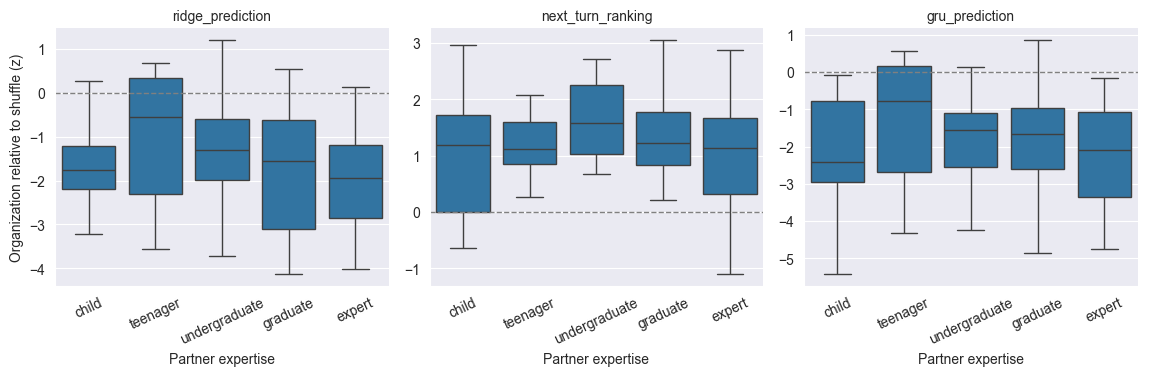

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

level_order = ["child", "teenager", "undergraduate", "graduate", "expert"]

g = sns.catplot(
    data=dynamic_method_scores,
    x="level_key",
    y="organization_z",
    col="method",
    col_wrap=3,
    order=level_order,
    kind="box",
    showfliers=False,
    sharey=False,
    height=3.5,
    aspect=1.1,
)

for ax in g.axes.flat:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.tick_params(axis="x", rotation=25)

g.set_axis_labels("Partner expertise", "Organization relative to shuffle (z)")
g.set_titles("{col_name}")
plt.show()

## Interpretation rules

- A method is useful only if its observed score generally exceeds its role-preserving shuffle score.
- Ridge and GRU prediction scores above zero mean they beat persistence; their organization gain asks whether they do so more strongly for real order than shuffled order.
- The GRU should not replace Ridge unless it improves held-out prediction and produces stable real-versus-shuffle gains.
- HMM and language-model gains are complementary evidence, not replacements for semantic geometry.
- Expertise effects should be compared across all methods and corrected for multiple testing.
- After the joint analysis is stable, set `TRAJECTORY_TYPES = ["joint", "expert", "partner"]` and rerun to separate interactional, expert, and partner organization.